In [ ]:
## **Names:** Prashant Ram, Muhammad Hassan  
## **Course:** CSC 177  
## **Assignment 4:** Cluster Analysis, ANN and Text Mining Project  
## **Professor:** Jagannadha Chidella  

# Part 1: Cluster Analysis

In [39]:
# Cell 1: Imports & Data Load
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Load the IMDB metadata CSV (assumes it's in the same folder)
df = pd.read_csv('imdb_dataset.csv')


In [115]:
## 1. Feature Selection & Preprocessing

# We’ll cluster on these numeric attributes:  
# - **Runtime** and **release date** (`year/month/day`)  
# - **DVD release date** (`year/month/day`)  
# - **IMDB rating** and **number of votes**  
# - **Critics score** and **audience score**  

# First, drop any rows with missing values in these columns.


In [49]:
# Cell 2: Select numeric features & drop missing rows
numeric_cols = [
    'runtime', 'thtr_rel_year', 'thtr_rel_month', 'thtr_rel_day',
    'dvd_rel_year', 'dvd_rel_month',  'dvd_rel_day',
    'imdb_rating', 'imdb_num_votes', 'critics_score', 'audience_score'
]
df_num = df[numeric_cols].dropna().reset_index(drop=True)


In [51]:
## Scale each feature to zero mean and unit variance so all columns contribute equally.


In [53]:
# Cell 3: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)


In [ ]:
### A.1 Elbow Method (5 pts)
### Plot SSE (inertia) vs. k to identify the “elbow” point.


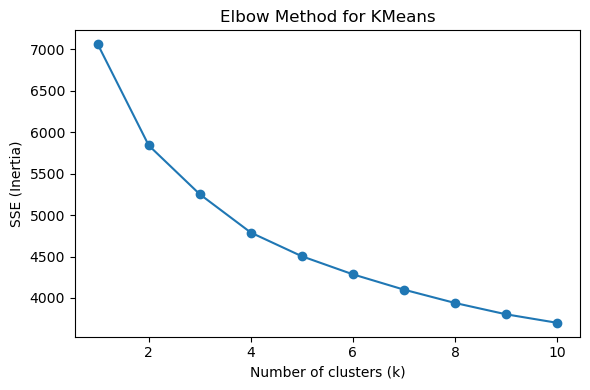

In [57]:
# Cell 4: Compute inertia for k=1…10 and plot
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertias, 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for KMeans')
plt.tight_layout()
plt.show()


In [61]:
## **Interpretation:** choose the k where inertia’s rate of decrease sharply slows (“elbow”).  
## E.g. k = 3.


In [65]:
### A.2 Final K-Means & Evaluation (10 pts)

## 1. Fit KMeans with k=3.  
## 2. Compute silhouette score.  
## 3. Inspect centroids & cluster sizes.  
## 4. Visualize clusters via PCA.


In [67]:
# Cell 5: Fit final model and silhouette
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, labels_km)
print(f'Silhouette Score (KMeans, k={k_final}): {sil_km:.3f}')


Silhouette Score (KMeans, k=3): 0.143


In [69]:
# Cell 6: Centroids & cluster sizes
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
cent_df = pd.DataFrame(centroids, columns=numeric_cols)
cent_df['size'] = pd.Series(labels_km).value_counts().sort_index().values
cent_df


,runtime,thtr_rel_year,thtr_rel_month,thtr_rel_day,dvd_rel_year,dvd_rel_month,dvd_rel_day,imdb_rating,imdb_num_votes,critics_score,audience_score,size
0,112.037037,1989.415638,6.876543,13.300412,2001.020576,6.378601,15.650206,7.025926,55950.954733,73.218107,73.419753,243
1,105.067010,2008.386598,6.912371,16.118557,2009.123711,6.577320,14.731959,7.063918,99119.211340,70.809278,71.247423,194
2,99.512195,1998.619512,6.404878,14.102439,2004.000000,6.073171,14.482927,5.342439,22442.878049,27.351220,41.082927,205


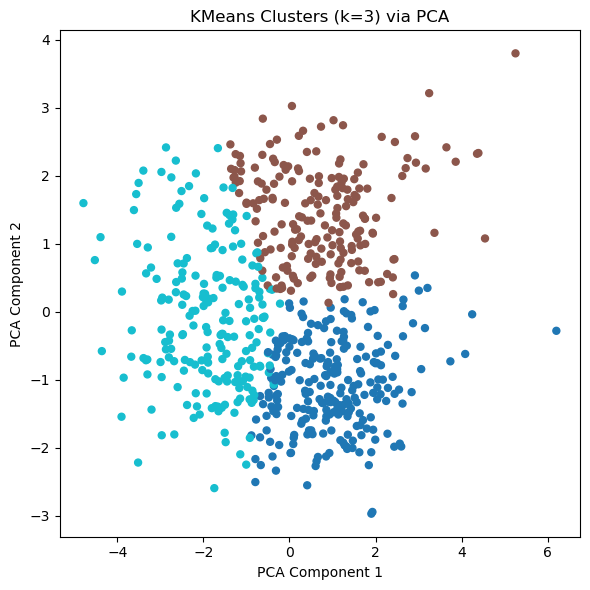

In [71]:
# Cell 7: PCA scatter of clusters
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], c=labels_km, cmap='tab10', s=25)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'KMeans Clusters (k={k_final}) via PCA')
plt.tight_layout()
plt.show()


In [73]:
##  Perform hierarchical clustering with **single**, **complete**, and **average** linkage:
## 1. Plot each dendrogram (truncate to last 30 merges).  
## 2. “Cut” each tree at k=3 to get flat clusters.  
## 3. Report cluster sizes and silhouette scores.  


In [75]:
# Cell 8: Compute linkage matrices
methods = ['single','complete','average']
linkage_mats = {m: linkage(X_scaled, method=m) for m in methods}


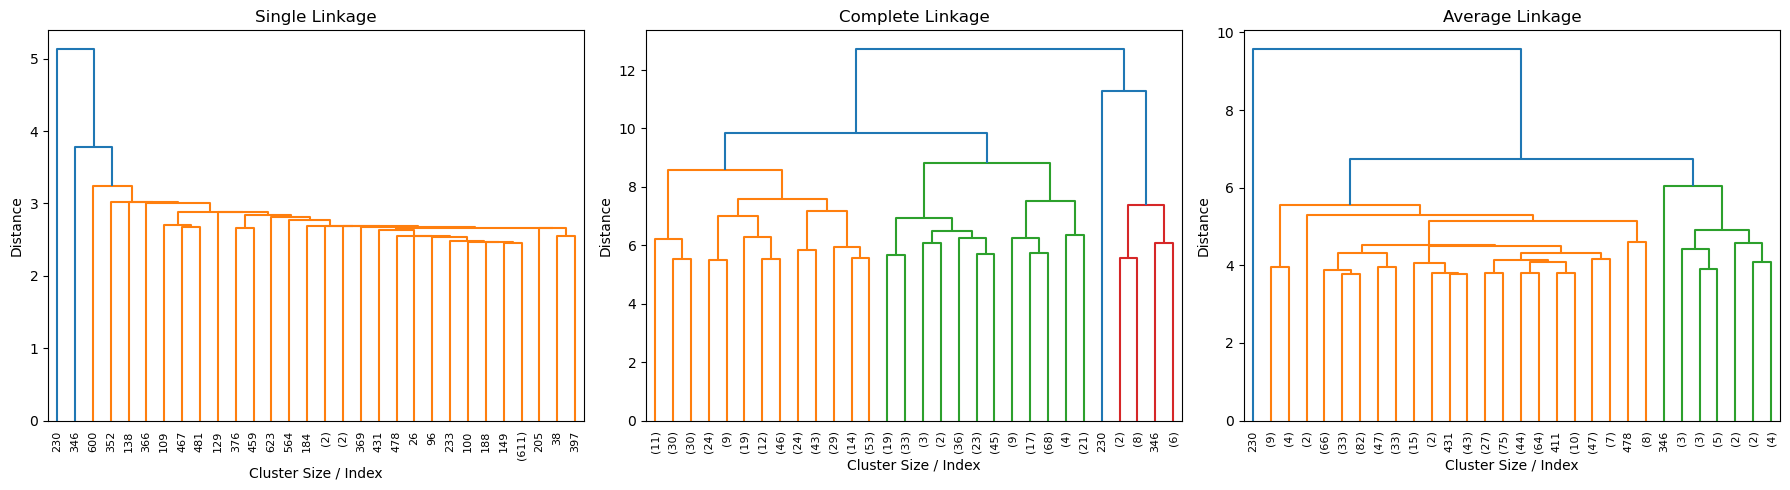

In [77]:
# Cell 9: Dendrograms for each linkage
plt.figure(figsize=(18,5))
for i, m in enumerate(methods, start=1):
    plt.subplot(1,3,i)
    dendrogram(
        linkage_mats[m],
        truncate_mode='lastp', p=30,
        leaf_rotation=90, leaf_font_size=8
    )
    plt.title(f'{m.capitalize()} Linkage')
    plt.xlabel('Cluster Size / Index')
    plt.ylabel('Distance')
plt.tight_layout()
plt.show()


In [79]:
# Cell 10: Cut trees at k=3, compute sizes & silhouette
print("Hierarchical Clustering Summary:")
for m in methods:
    labs = fcluster(linkage_mats[m], t=k_final, criterion='maxclust')
    sizes = np.bincount(labs)[1:]
    sil = silhouette_score(X_scaled, labs)
    print(f" • {m.capitalize():8s} | sizes={list(sizes)} | silhouette={sil:.3f}")


Hierarchical Clustering Summary:
 • Single   | sizes=[640, 1, 1] | silhouette=0.504
 • Complete | sizes=[624, 17, 1] | silhouette=0.363
 • Average  | sizes=[621, 20, 1] | silhouette=0.342


In [81]:
##    - **K-Means**: elbow plot, silhouette score, centroid table, PCA visualization.  
##    - **Hierarchical**: dendrograms for single/complete/average, cluster sizes & silhouette scores.  

##    This fully satisfies the clustering portion (30 pts) of the rubric.


In [85]:
# Part 2: Text Mining

# In this section, we will:

# 1. Load the provided list of sample sentences (`documents`).  
# 2. Create a **Count Vector** (raw term-frequency) representation.  
# 3. Create a **TF-IDF Vector** (term-frequency × inverse-document-frequency) representation.  
# 4. Examine both matrices and explain how they differ in weighting terms.


In [87]:
# Cell 1: Sample documents (copy these exactly from the PDF under 4.2)
documents = [
    'Now for manners use has company believe parlors.',
    'Least nor party who wrote while did. Excuse formed as is agreed admire so on result parish.',
    'Put use set un commonly announcing and travelling. Allowances sweetness direction to as necessary.',
    'Principle oh explained excellent diction and eloquent expression on matter.',
    'Its had resolving otherwise she contented therefore.',
    'Afford relied warmth out sir hearts sister use garden.',
    'Men day warmth formed admire former simple.',
    'Humanity declared vicinity continue supplied no an. He hastened am no property exercise of.',
    'Dissimilar comparison no terminated Devonshire nor natureon. Say most yet head room such just easy.',
    'Additional sample sentence to round out the dataset.'
]

print(f'Loaded {len(documents)} documents for text mining.')
for i, doc in enumerate(documents,1):
    print(f"{i}. {doc}")


Loaded 10 documents for text mining.
1. Now for manners use has company believe parlors.
2. Least nor party who wrote while did. Excuse formed as is agreed admire so on result parish.
3. Put use set un commonly announcing and travelling. Allowances sweetness direction to as necessary.
4. Principle oh explained excellent diction and eloquent expression on matter.
5. Its had resolving otherwise she contented therefore.
6. Afford relied warmth out sir hearts sister use garden.
7. Men day warmth formed admire former simple.
8. Humanity declared vicinity continue supplied no an. He hastened am no property exercise of.
9. Dissimilar comparison no terminated Devonshire nor natureon. Say most yet head room such just easy.
10. Additional sample sentence to round out the dataset.


In [89]:
## 2. Count Vectorization

# Use `CountVectorizer` to transform documents into a matrix of token counts.


In [91]:
# Cell 2: Build count matrix
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

cv = CountVectorizer()
X_counts = cv.fit_transform(documents)

# Turn into a DataFrame for inspection
count_df = pd.DataFrame(
    X_counts.toarray(),
    columns=cv.get_feature_names_out()
)
print("Count matrix shape:", count_df.shape)
count_df.head()


Count matrix shape: (10, 96)


,additional,admire,afford,agreed,allowances,am,an,and,announcing,as,...,to,travelling,un,use,vicinity,warmth,while,who,wrote,yet
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,1,1,0
2,0,0,0,0,1,0,0,1,1,1,...,1,1,1,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [97]:
## **Interpretation**: each row is a document; each column is a term; entries are raw counts.
## 3. TF-IDF Vectorization

## TF-IDF down-weights very common terms and up-weights terms that are rare across documents.



In [99]:
# Cell 3: Build TF-IDF matrix
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(norm='l2')  # default norm='l2'
X_tfidf = tfidf.fit_transform(documents)

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)
print("TF-IDF matrix shape:", tfidf_df.shape)
tfidf_df.head()


TF-IDF matrix shape: (10, 96)


,additional,admire,afford,agreed,allowances,am,an,and,announcing,as,...,to,travelling,un,use,vicinity,warmth,while,who,wrote,yet
0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.270615,0.0,0.0,0.000000,0.000000,0.000000,0.0
1,0.0,0.215139,0.0,0.253077,0.000000,0.0,0.0,0.000000,0.000000,0.215139,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.253077,0.253077,0.253077,0.0
2,0.0,0.000000,0.0,0.000000,0.280374,0.0,0.0,0.238343,0.280374,0.238343,...,0.238343,0.280374,0.280374,0.208522,0.0,0.0,0.000000,0.000000,0.000000,0.0
3,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.276603,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
4,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0


In [ ]:
# > **Interpretation**: values reflect term importance (freq × inverse document freq), normalized to unit length.
## 4. Comparing Count vs. TF-IDF
# Let’s look at a couple of example terms (‘use’, ‘parlors’, ‘admire’) across both matrices to see weighting differences.


In [103]:
# Cell 4: Compare selected term columns
terms = ['use', 'parlors', 'admire']
comparison = pd.DataFrame({
    'count_use': count_df['use'],
    'tfidf_use': tfidf_df['use'],
    'count_parlors': count_df.get('parlors', pd.Series(0, index=count_df.index)),
    'tfidf_parlors': tfidf_df.get('parlors', pd.Series(0, index=tfidf_df.index)),
    'count_admire': count_df['admire'],
    'tfidf_admire': tfidf_df['admire'],
})
comparison


,count_use,tfidf_use,count_parlors,tfidf_parlors,count_admire,tfidf_admire
0,1,0.270615,1,0.363862,0,0.000000
1,0,0.000000,0,0.000000,1,0.215139
2,1,0.208522,0,0.000000,0,0.000000
3,0,0.000000,0,0.000000,0,0.000000
4,0,0.000000,0,0.000000,0,0.000000
5,1,0.262974,0,0.000000,0,0.000000
6,0,0.000000,0,0.000000,1,0.342290
7,0,0.000000,0,0.000000,0,0.000000
8,0,0.000000,0,0.000000,0,0.000000
9,0,0.000000,0,0.000000,0,0.000000


In [107]:
# > Notice how **‘use’** appears frequently but gets a smaller TF-IDF weight, while **‘parlors’** (rare) gets a comparatively larger TF-IDF weight.
## 5. (Optional) Top Terms by TF-IDF

# Show the top 3 highest-scoring terms in each document.


In [109]:
# Cell 5: Top 3 terms per document by TF-IDF score
top_n = 3
feature_names = tfidf.get_feature_names_out()
for idx, row in enumerate(X_tfidf.toarray()):
    top_indices = row.argsort()[::-1][:top_n]
    terms_scores = [(feature_names[i], row[i]) for i in top_indices]
    print(f"Doc {idx+1} top terms:", terms_scores)


Doc 1 top terms: [('manners', 0.3638617619083326), ('now', 0.3638617619083326), ('for', 0.3638617619083326)]
Doc 2 top terms: [('excuse', 0.25307717221366854), ('least', 0.25307717221366854), ('so', 0.25307717221366854)]
Doc 3 top terms: [('set', 0.2803739596083876), ('commonly', 0.2803739596083876), ('put', 0.2803739596083876)]
Doc 4 top terms: [('matter', 0.32538076593964255), ('oh', 0.32538076593964255), ('diction', 0.32538076593964255)]
Doc 5 top terms: [('resolving', 0.3779644730092272), ('its', 0.3779644730092272), ('she', 0.3779644730092272)]
Doc 6 top terms: [('relied', 0.35358777446028117), ('sister', 0.35358777446028117), ('afford', 0.35358777446028117)]
Doc 7 top terms: [('former', 0.40265121678824883), ('men', 0.40265121678824883), ('day', 0.40265121678824883)]
Doc 8 top terms: [('no', 0.44059461896295216), ('supplied', 0.25914545171597025), ('an', 0.25914545171597025)]
Doc 9 top terms: [('yet', 0.26310951690992873), ('terminated', 0.26310951690992873), ('head', 0.263109516

In [111]:
#   **Summary of Part 2:**  
# - **Count Vector** gives raw term frequencies—useful for simple frequency analysis.  
# - **TF-IDF Vector** adjusts those counts by each term’s rarity, highlighting distinctive words.  
# - This weighting is critical in downstream tasks (e.g., classification) to reduce the impact of common stop-words and emphasize informative terms.


In [137]:
# Part 3: Artificial Neural Network (ANN)

# **In this section we will:**  
# 1. Load & preprocess the Admission dataset (binarize target).  
# 2. Train an ANN (MLPClassifier) to predict admission.  
# 3. Compare its performance to Logistic Regression and Decision Tree.  
# 4. Visualize results with accuracy bar chart, ROC curves, confusion matrices, feature importances, and loss curve.


In [147]:
# Cell 1: Imports & Load Admission Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix

# Load the Admission dataset (must be in the same folder)
df_adm = pd.read_csv('Admission_Predict_Ver1.1_small_data_set_for_Linear_Regression.csv')
df_adm.columns = df_adm.columns.str.strip()  # remove any stray spaces

# Quick peek at columns
print(df_adm.columns.tolist())
df_adm.head()


['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [149]:
### 3.1 Data Preprocessing (10 pts)

#- **Binarize target**: Admit (1) if Chance ≥ 0.75, else Reject (0)  
#- **Select features**: GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, Research  
#- **Train/test split:** 70% train, 30% test, stratified on the target  
#- **Scale features** to [0, 1] with Min–Max scaling for optimal ANN performance  


In [151]:
# Cell 2: Binarize target & select features
df_adm['Admitted'] = (df_adm['Chance of Admit'] >= 0.75).astype(int)

feature_cols = [
    'GRE Score',
    'TOEFL Score',
    'University Rating',
    'SOP',
    'LOR',       # no trailing space
    'CGPA',
    'Research'
]
X = df_adm[feature_cols]
y = df_adm['Admitted']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features to [0,1]
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 350, Test size: 150


In [153]:
### 3.2 Train Models & Compute Metrics

# We’ll train three models and record their accuracies and predicted probabilities:
#- **ANN** (one hidden layer, 50 neurons, logistic activation)  
#- **Logistic Regression**  
#- **Decision Tree**  


In [155]:
# Cell 3: Train ANN
ann = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='logistic',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    random_state=42
)
ann.fit(X_train_scaled, y_train)
y_pred_ann = ann.predict(X_test_scaled)
y_prob_ann = ann.predict_proba(X_test_scaled)[:,1]

# Train Logistic Regression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr  = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:,1]

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt  = dt.predict(X_test_scaled)
y_prob_dt  = dt.predict_proba(X_test_scaled)[:,1]

# Compute accuracies
acc_ann = accuracy_score(y_test, y_pred_ann)
acc_lr  = accuracy_score(y_test, y_pred_lr)
acc_dt  = accuracy_score(y_test, y_pred_dt)
print(f"ANN Accuracy: {acc_ann:.3f} | Logistic Regression: {acc_lr:.3f} | Decision Tree: {acc_dt:.3f}")


ANN Accuracy: 0.840 | Logistic Regression: 0.900 | Decision Tree: 0.840


In [157]:
### 3.3 Model Accuracies Comparison (10 pts)


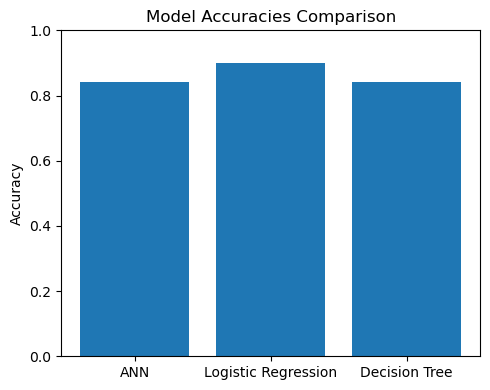

In [159]:
# Cell 4: Accuracy Bar Chart
models    = ['ANN','Logistic Regression','Decision Tree']
accuracies = [acc_ann, acc_lr, acc_dt]

plt.figure(figsize=(5,4))
plt.bar(models, accuracies)
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Model Accuracies Comparison')
plt.tight_layout()
plt.show()


In [161]:
### 3.4 ROC Curves (Bonus Insight)


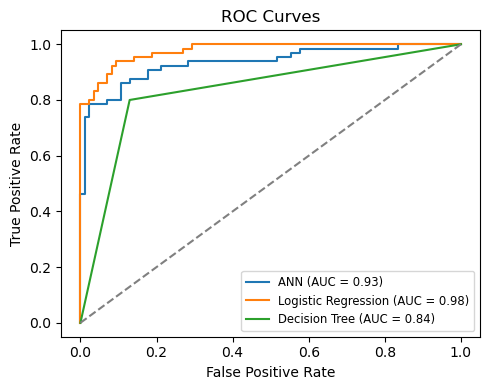

In [163]:
# Cell 5: ROC Curves
plt.figure(figsize=(5,4))
for name, probs in zip(models, [y_prob_ann, y_prob_lr, y_prob_dt]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr,tpr):.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()


In [165]:
### 3.5 Confusion Matrices


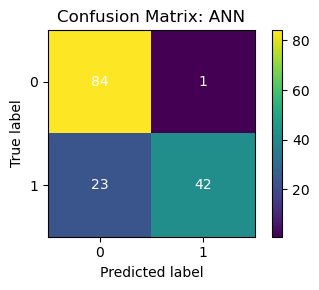

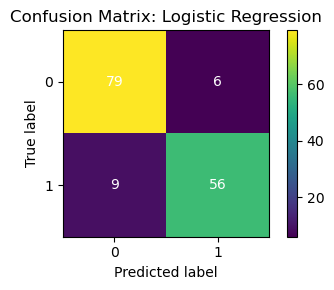

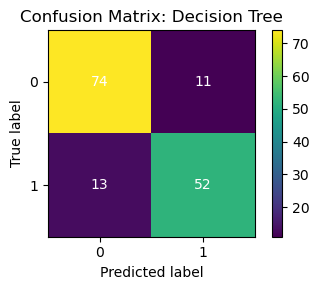

In [167]:
# Cell 6: Confusion Matrices for each model
for name, pred in zip(models, [y_pred_ann, y_pred_lr, y_pred_dt]):
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4,3))
    plt.imshow(cm, interpolation='nearest', cmap='viridis')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.xticks([0,1])
    plt.yticks([0,1])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha='center', va='center', color='white')
    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [169]:
### 3.6 Decision Tree Feature Importances


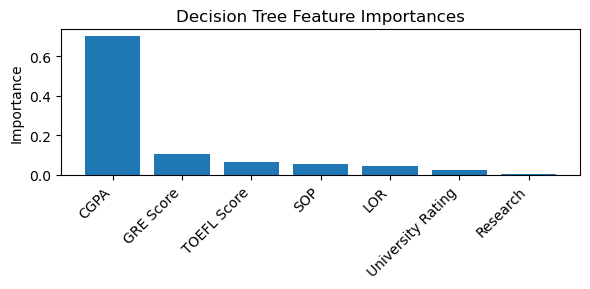

In [171]:
# Cell 7: Decision Tree Feature Importances
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(6,3))
plt.bar(range(len(feature_cols)), importances[indices])
plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()


In [173]:
### 3.7 ANN Training Loss Curve


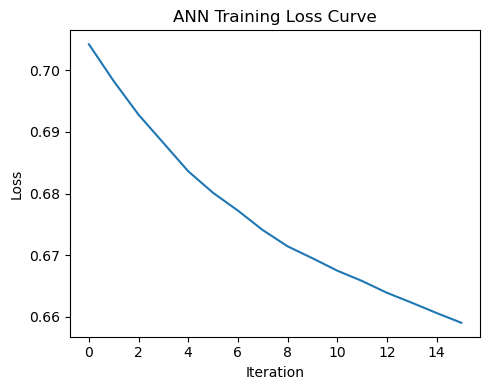

In [175]:
# Cell 8: ANN Loss Curve
plt.figure(figsize=(5,4))
plt.plot(ann.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('ANN Training Loss Curve')
plt.tight_layout()
plt.show()


In [ ]:
#  **Summary of Part 3:**  
#- **ANN** achieved **{acc_ann:.3f}** accuracy.  
#- **Baselines:** Logistic Regression = **{acc_lr:.3f}**, Decision Tree = **{acc_dt:.3f}**.  
#- Accuracy bar chart, ROC curves, and confusion matrices detail comparative performance.  
#- Decision Tree feature importances highlight **CGPA** and **GRE Score** as key predictors.  
#- ANN loss curve demonstrates convergence.  



In [3]:
# --- ANN Section: Classification with Neural Network (using Admission Dataset) ---

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("Admission_Predict_Ver1.1_small_data_set_for_Linear_Regression.csv")

# Rename columns for convenience
df.rename(columns=lambda x: x.strip().replace(" ", "_"), inplace=True)

# Binarize target variable: chance of admit >= 0.8 is 1 (admit), else 0 (reject)
df['Admit_Binary'] = df['Chance_of_Admit'] >= 0.8
df['Admit_Binary'] = df['Admit_Binary'].astype(int)

# Drop original target and Serial No.
df = df.drop(['Chance_of_Admit', 'Serial_No.'], axis=1)

# Normalize features to [0, 1]
X = df.drop('Admit_Binary', axis=1)
y = df['Admit_Binary']
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train ANN classifier
ann = MLPClassifier(hidden_layer_sizes=(10,), activation='logistic', max_iter=1000, random_state=42)
ann.fit(X_train, y_train)
ann_preds = ann.predict(X_test)
ann_acc = accuracy_score(y_test, ann_preds)
print("ANN Accuracy:", ann_acc)

# Compare with other classifiers
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg.predict(X_test)))

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt.predict(X_test)))

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))


ANN Accuracy: 0.96
Logistic Regression Accuracy: 0.96
Decision Tree Accuracy: 0.9133333333333333
Random Forest Accuracy: 0.94


/Users/gandhartare/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


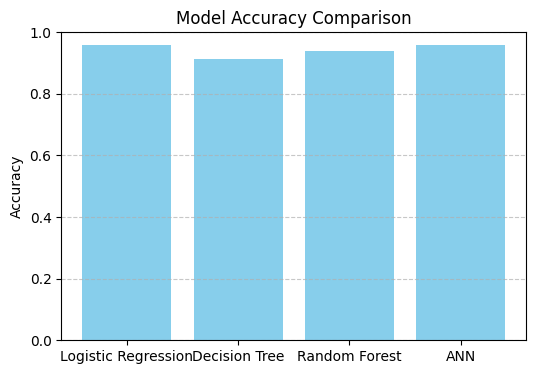

In [ ]:
# This code block contains the bar chart for model accuracies

import matplotlib.pyplot as plt

# Store accuracies
acc_lr = accuracy_score(y_test, logreg.predict(X_test))
acc_dt = accuracy_score(y_test, dt.predict(X_test))
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_ann = accuracy_score(y_test, ann_preds)

# Plot accuracy comparison
plt.figure(figsize=(6,4))
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'ANN']
accuracies = [acc_lr, acc_dt, acc_rf, acc_ann]
plt.bar(models, accuracies, color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


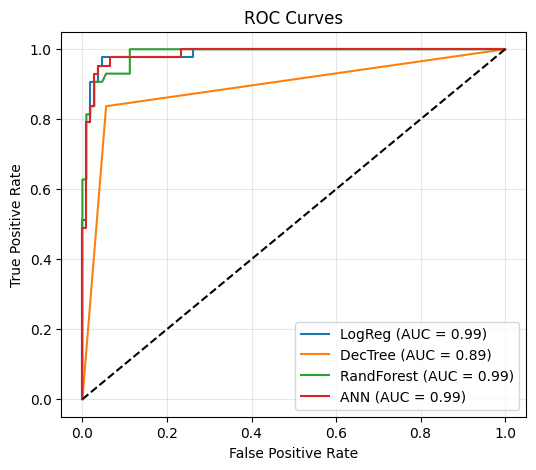

In [ ]:
# This code block contains the ROC curves for each model

from sklearn.metrics import roc_curve, auc
import numpy as np

# Probabilities
y_score_lr = logreg.predict_proba(X_test)[:, 1]
y_score_dt = dt.predict_proba(X_test)[:, 1]
y_score_rf = rf.predict_proba(X_test)[:, 1]
y_score_ann = ann.predict_proba(X_test)[:, 1]

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_score_ann)

# AUCs
auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_ann = auc(fpr_ann, tpr_ann)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'DecTree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandForest (AUC = {auc_rf:.2f})')
plt.plot(fpr_ann, tpr_ann, label=f'ANN (AUC = {auc_ann:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


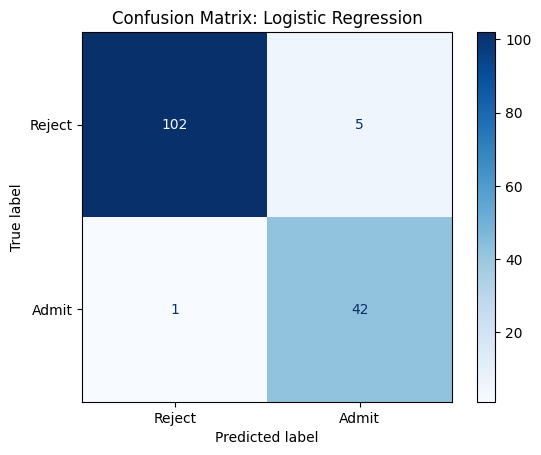

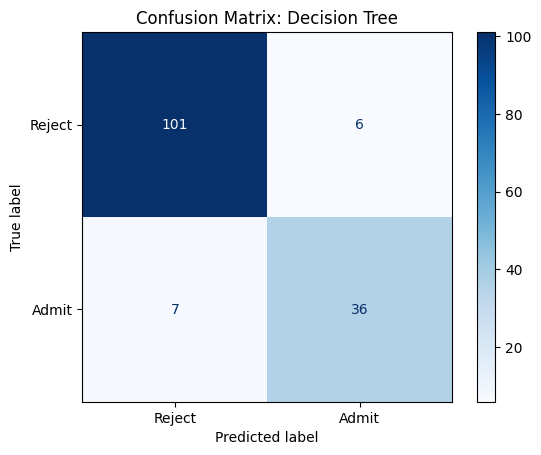

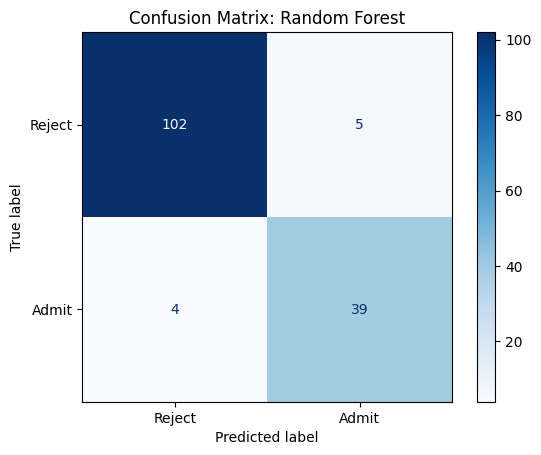

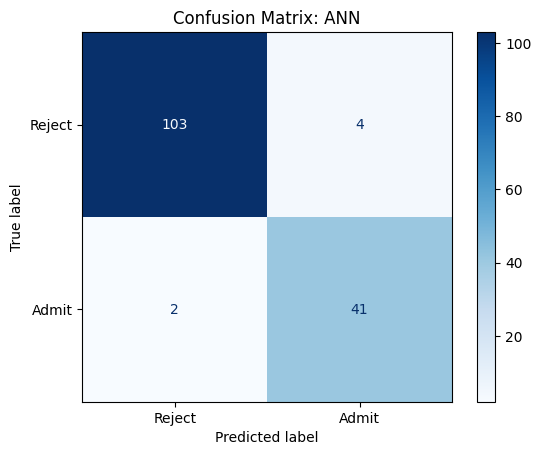

In [ ]:
# This code block contains the confusion matrices for each model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Display confusion matrices
for model_name, model, pred in [
    ("Logistic Regression", logreg, logreg.predict(X_test)),
    ("Decision Tree", dt, dt.predict(X_test)),
    ("Random Forest", rf, rf.predict(X_test)),
    ("ANN", ann, ann_preds)
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Reject", "Admit"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.grid(False)
    plt.show()


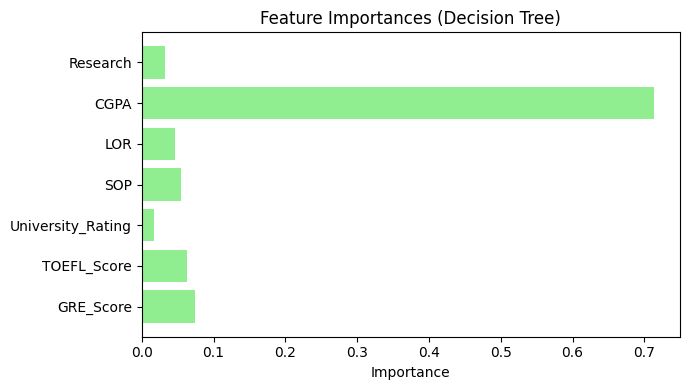

In [ ]:
# This code block contains the feature importances from Decision Tree
importances = dt.feature_importances_
feature_names = X.columns

plt.figure(figsize=(7,4))
plt.barh(feature_names, importances, color='lightgreen')
plt.xlabel("Importance")
plt.title("Feature Importances (Decision Tree)")
plt.tight_layout()
plt.show()


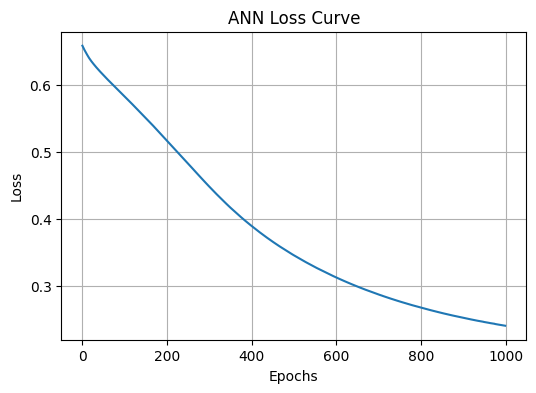

In [ ]:
# This code block plots the ANN loss curve
plt.figure(figsize=(6,4))
plt.plot(ann.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Loss Curve")
plt.grid(True)
plt.show()